## ASSIGNMENT 7-VB

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
oc_df= pd.read_csv('Online Customers')

In [3]:
oc_df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
oc_df.shape

(500, 8)

In [5]:
oc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
oc_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Avg. Session Length,500.0,33.053194,0.992563,29.532429,32.341822,33.082008,33.711985,36.139662
Time on App,500.0,12.052488,0.994216,8.508152,11.388153,11.983231,12.753850,15.126994
Time on Website,500.0,37.060445,1.010489,33.913847,36.349257,37.069367,37.716432,40.005182
Length of Membership,500.0,3.533462,0.999278,0.269901,2.930450,3.533975,4.126502,6.922689
Yearly Amount Spent,500.0,499.314038,79.314782,256.670582,445.038277,498.887875,549.313828,765.518462


In [7]:
#mean of yearly amount spent
499.314038

499.314038

## 2. EDA

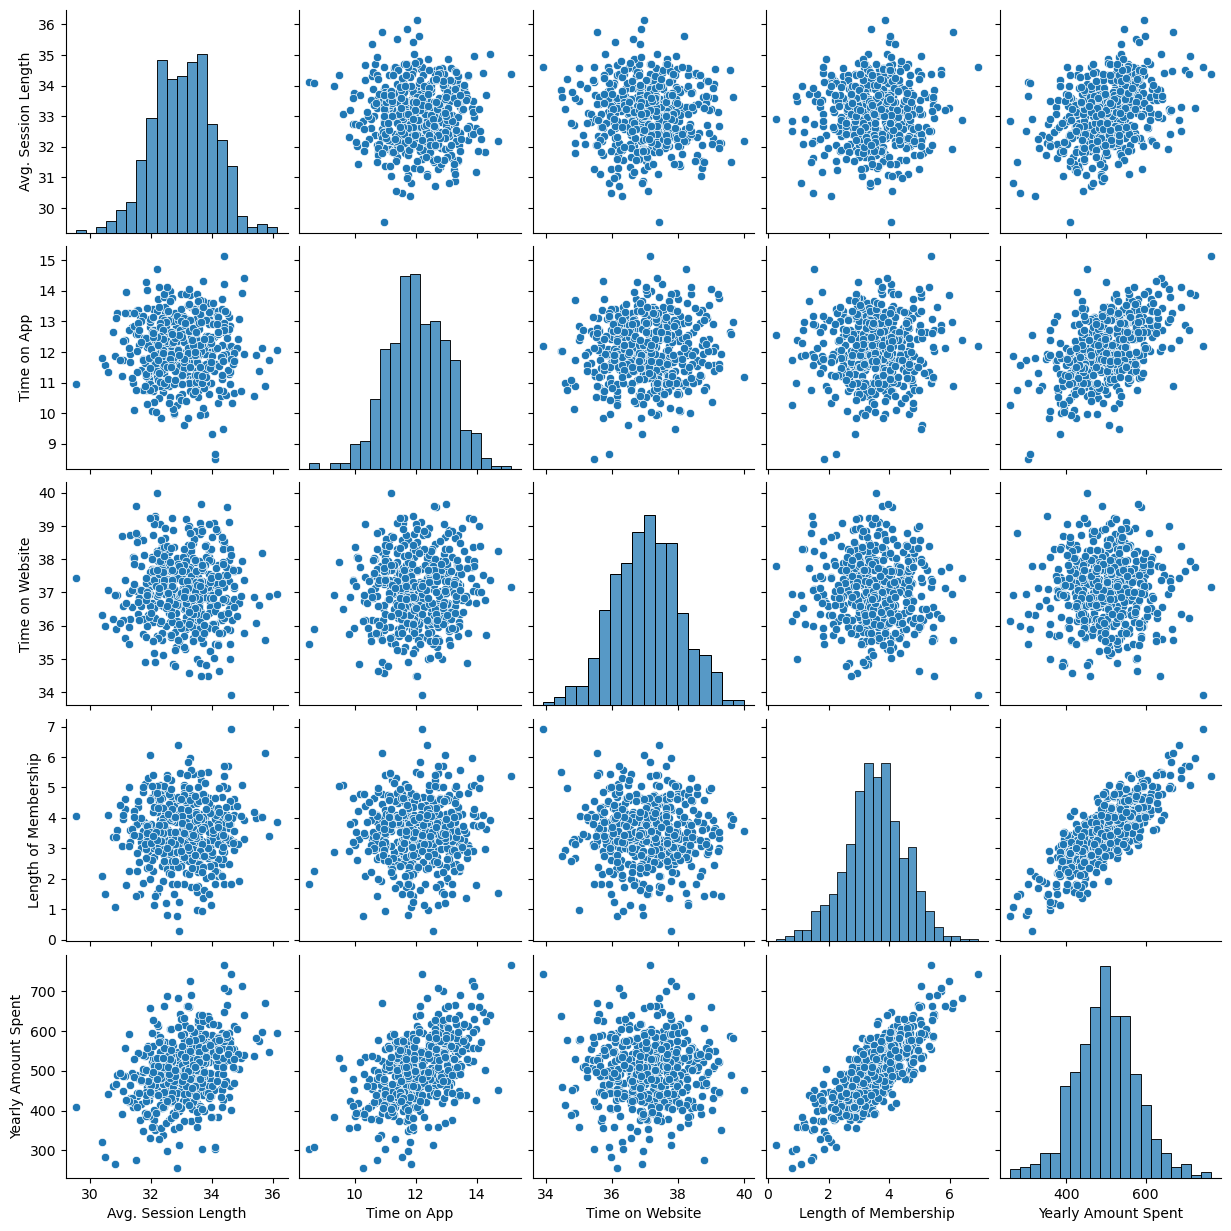

In [8]:
sns.pairplot(oc_df)
plt.show()

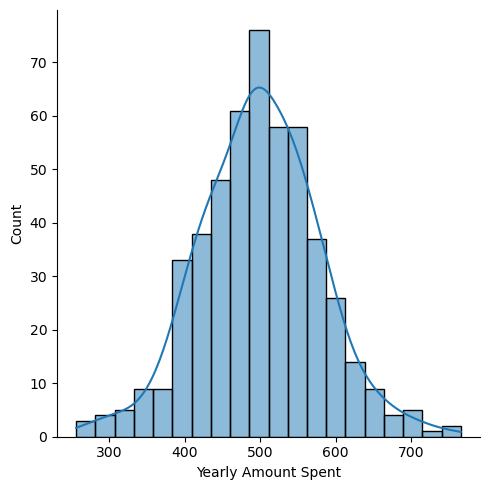

In [9]:
sns.displot(oc_df['Yearly Amount Spent'], kde=True)
plt.show()

In [10]:
oc_df_new = oc_df.drop(columns=['Email','Address','Avatar'])
oc_df_new.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [11]:
oc_df_new.corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


In [12]:
sns.heatmap(oc_df_new.corr(), annot=True)

<Axes: >

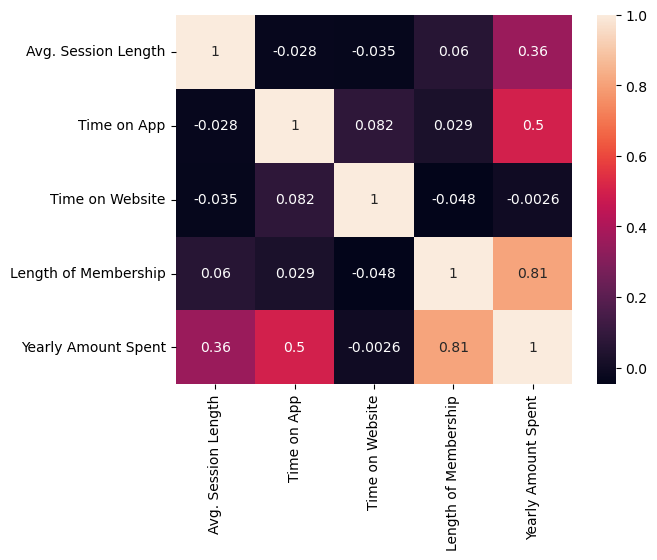

In [13]:
plt.show()

In [14]:
x = oc_df_new[['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership']]
y = oc_df_new['Yearly Amount Spent']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
# splitting the data into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=101)

## 3. Linear regression model

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lm = LinearRegression()

In [19]:
#now we now train our model
lm.fit(x_train, y_train)

LinearRegression()

In [20]:
# printing the intercept
print(lm.intercept_)

-1045.1152168245753


In [21]:
lm.coef_

array([25.69154034, 37.89259966,  0.56058149, 61.64859402])

In [22]:
# x.columns
coeff_df = pd.DataFrame(lm.coef_, x.columns, columns=['Coefficient'])

In [23]:
coeff_df

,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


In [24]:
predictions = lm.predict(x_test)

In [25]:
plt.scatter(y_test,predictions)

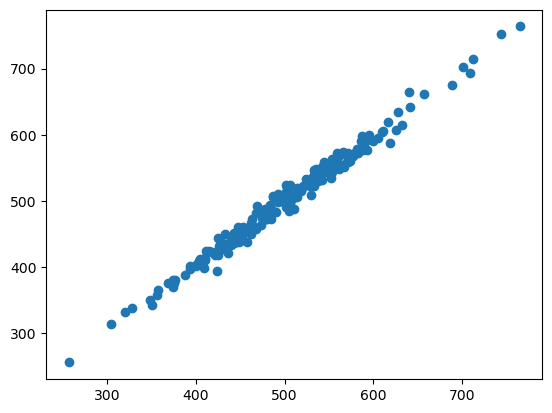

In [26]:
plt.show()

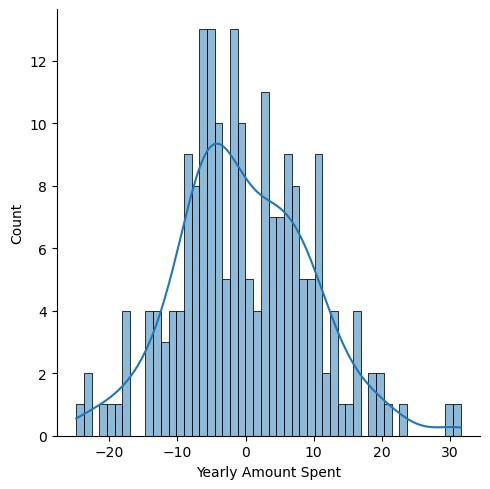

In [27]:
sns.displot((y_test-predictions),kind='hist',kde=True,bins=50)
plt.show()

In [28]:
from sklearn import metrics

In [29]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.7426712858387425
MSE: 93.83297800820114
RMSE: 9.68674238370161


In [30]:
#understanding RMSE of our model
9.686742/499.314038*100

1.940009946205438

## 4. Recommended choice

## The mobile App should be prioritized over the Website.  

The mobile App should be prioritized over the Website. The correlation analysis between Time on App (0.50) and Yearly Amount Spent shows stronger relationship than Time on Website (-0.002). This shows that customers are more engaging with the App are likely to spend more, making the App the better investment.
